In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## imports

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

## loading Dataset

In [2]:
try:
  df = pd.read_csv('/kaggle/input/boston-housing-dataset/BostonHousing.csv')
except FileNotFoundError:
  try:
    df = pd.read_csv('/content/drive/MyDrive/Data sets/boston housing project/bostonHousingDatakeggel.csv')
  except FileNotFoundError:
    df = pd.read_csv("E:/Datasets/boston housing project/bostonHousingDatakeggel.csv")

## Basics of data checks for data understanding

In [3]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [5]:
df.isnull().sum()

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


In [6]:
size = df.shape
size

(506, 14)

In [7]:
col_list = df.columns.tolist()
col_list

['CRIM',
 'ZN',
 'INDUS',
 'CHAS',
 'NOX',
 'RM',
 'AGE',
 'DIS',
 'RAD',
 'TAX',
 'PTRATIO',
 'B',
 'LSTAT',
 'MEDV']

## Data Cleaning and Processing and Handling Outliers

In [8]:
# Duplicate values
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


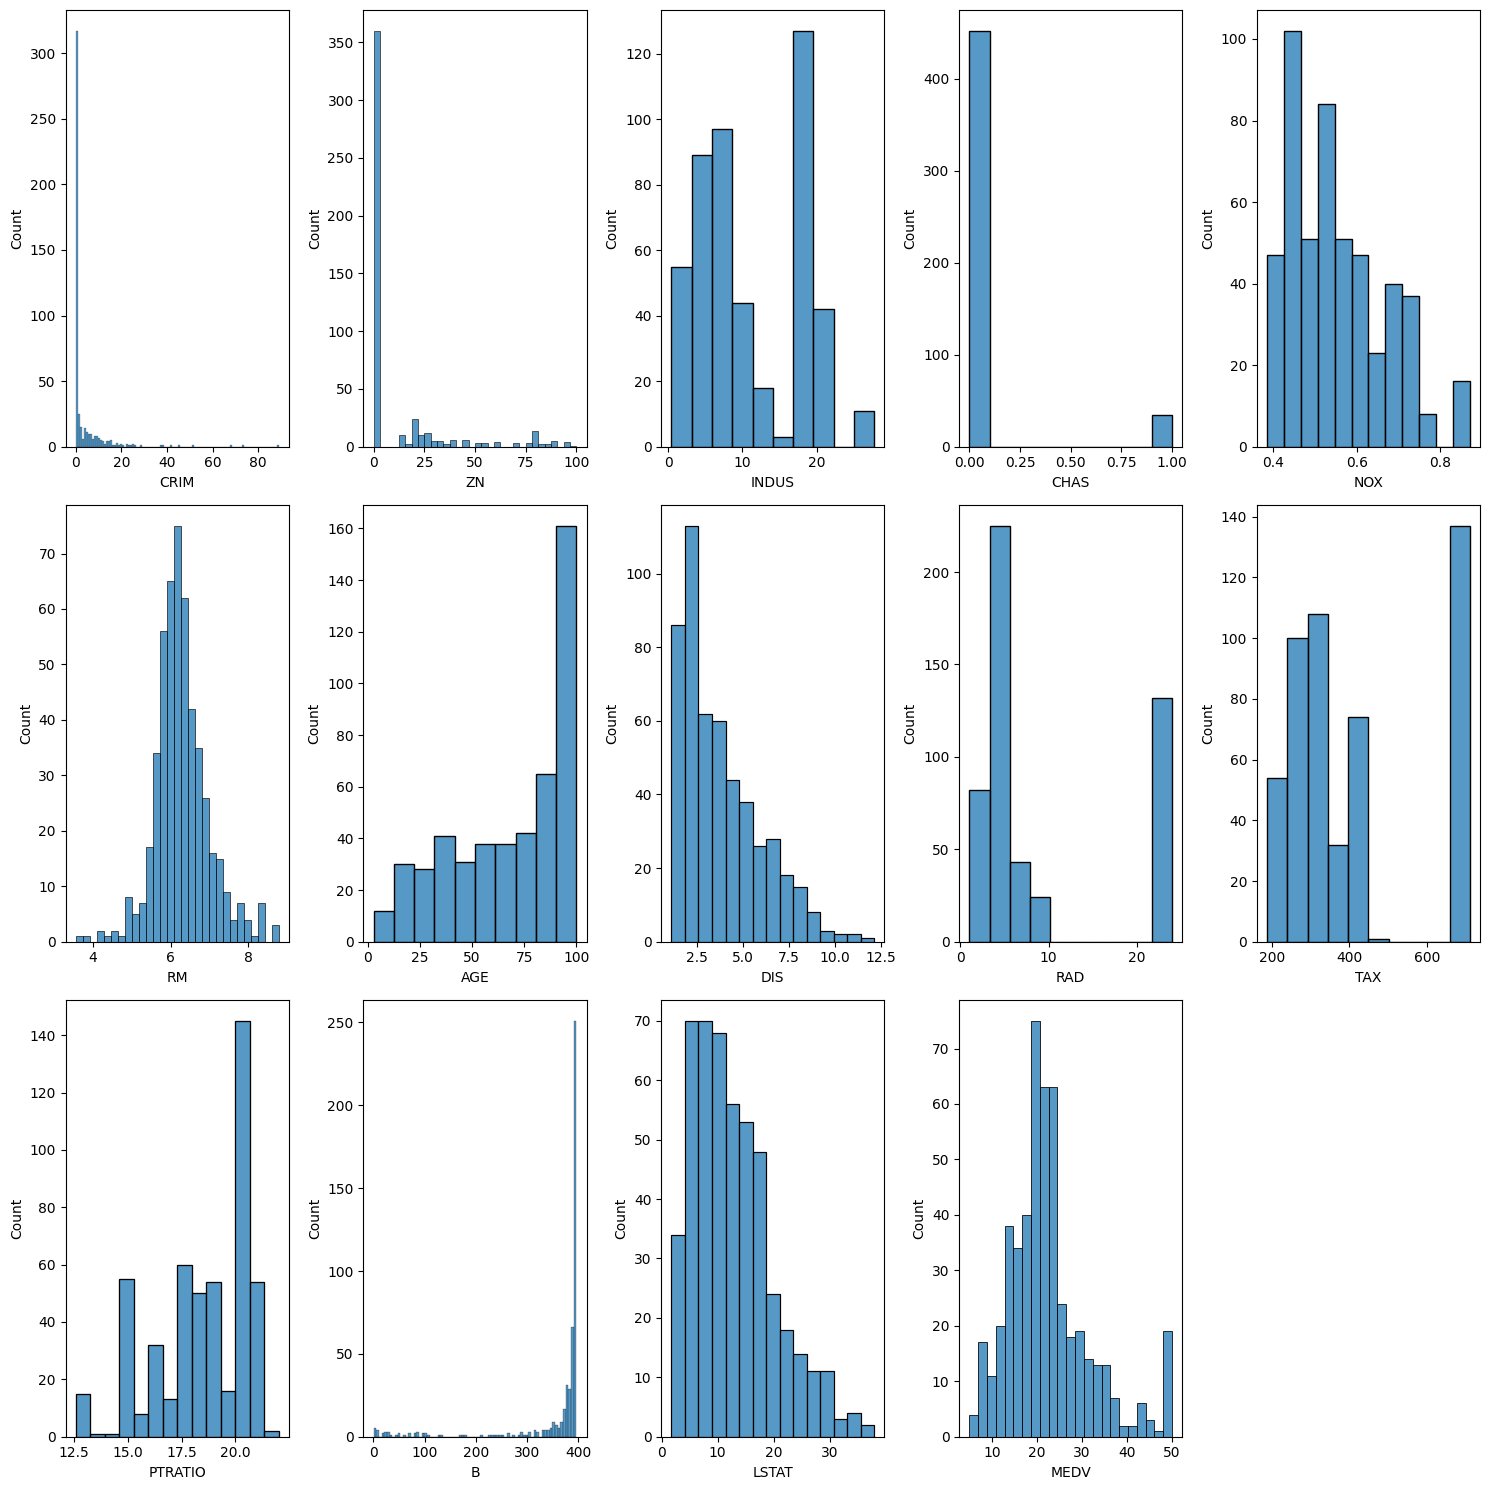

In [10]:
n = 1
plt.figure(figsize=(15, 15))
for i in df.columns:
  if n <= len(df.columns):
    ax = plt.subplot(3, 5, n)
    sns.histplot(x=df[i])
  n += 1
plt.tight_layout()
plt.show()

In [11]:
df['CRIM'] = df['CRIM'].fillna(df['CRIM'].median())
df['ZN'] = df['ZN'].fillna(df['ZN'].median())
df['INDUS'] = df['INDUS'].fillna(df['INDUS'].mean())
df['AGE'] = df['AGE'].fillna(df['AGE'].median())
df['LSTAT'] = df['LSTAT'].fillna(df['LSTAT'].median())
df['CHAS'] = df['CHAS'].fillna(0)

In [12]:
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


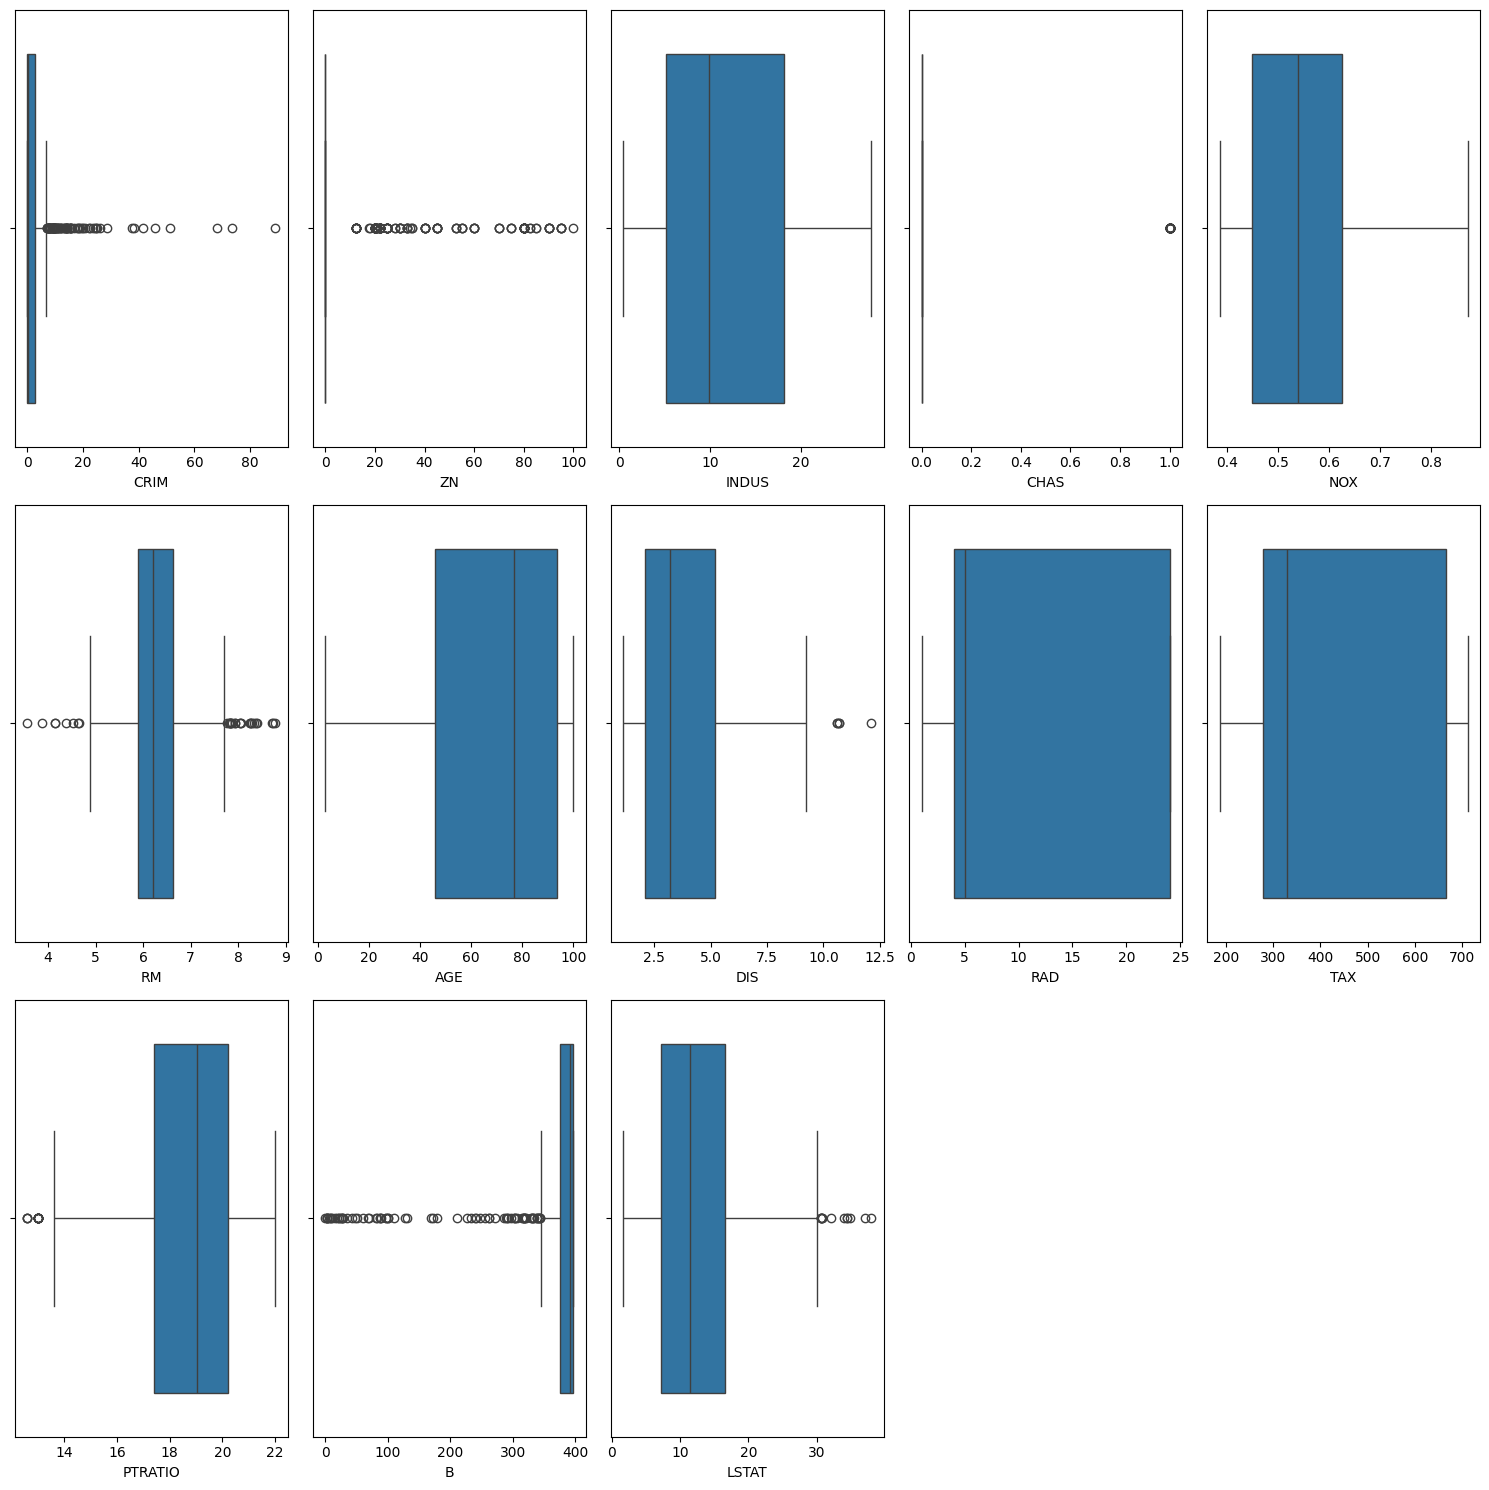

In [13]:
n = 1
plt.figure(figsize=(15, 15))
for i in df.drop(columns='MEDV').columns:
  if n <= len(df.columns):
    ax = plt.subplot(3, 5, n)
    sns.boxplot(x=df[i])
  n += 1
plt.tight_layout()
plt.show()

In [14]:
for i in df.columns:
    if i == 'MEDV':
        continue
    if i == 'CHAS':
        continue
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier = df[(df[i] < lower) | (df[i] > upper)].index
    df = df.drop(outlier)


## Conclusion
### Data seems to well cleaned and proccesed

# Exploratory Data Analysis

In [15]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
CRIM,254.0,0.240216,0.287674,0.00632,0.069320,0.136145,0.261055,2.24236
ZN,254.0,7.606299,12.806114,0.00000,0.000000,0.000000,19.500000,45.00000
INDUS,254.0,8.287362,5.057184,1.25000,4.980000,7.070000,10.010000,25.65000
CHAS,254.0,0.059055,0.236193,0.00000,0.000000,0.000000,0.000000,1.00000
NOX,254.0,0.501585,0.061510,0.40900,0.447000,0.493000,0.538000,0.64700
RM,254.0,6.313780,0.471075,5.39000,5.961500,6.218500,6.592250,7.64500
AGE,254.0,61.098425,25.696952,2.90000,41.650000,62.900000,82.750000,100.00000
DIS,254.0,4.322482,1.725009,1.66860,2.849275,4.083800,5.481500,9.22290
RAD,254.0,4.570866,1.625178,1.00000,4.000000,4.500000,5.000000,8.00000
TAX,254.0,304.125984,65.183171,188.00000,264.000000,296.000000,330.000000,437.00000


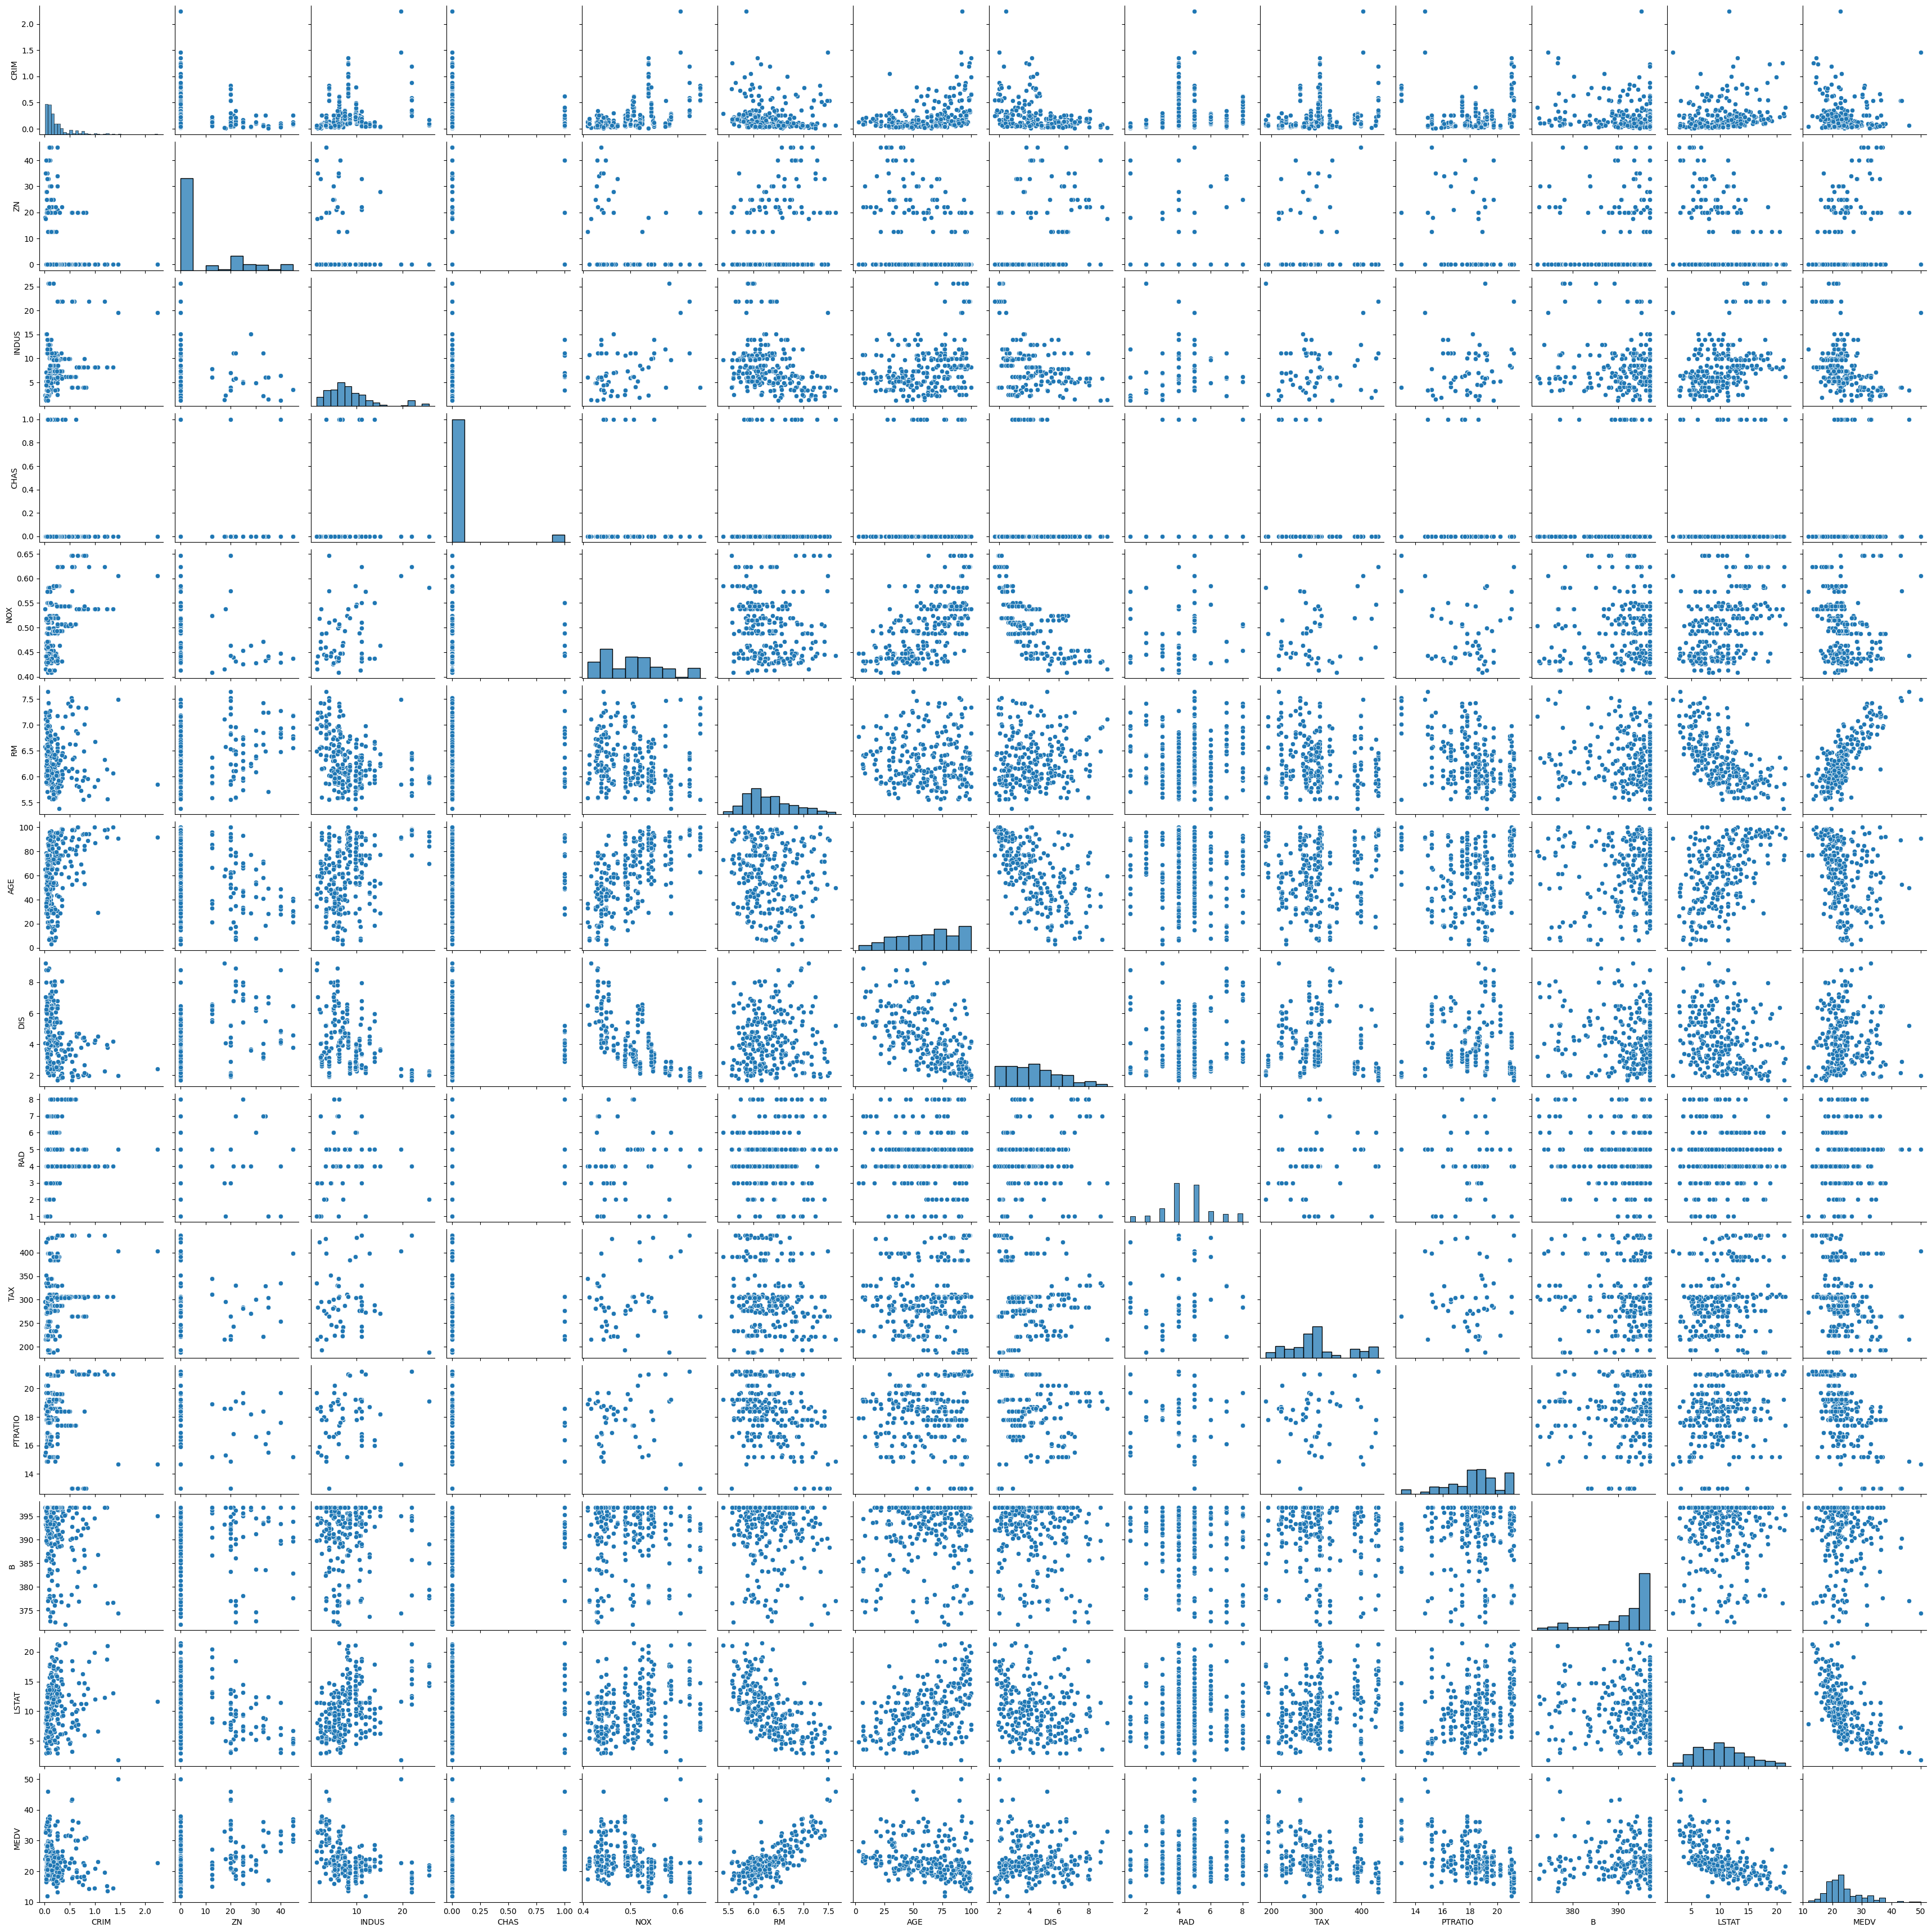

In [16]:
sns.pairplot(data=df)

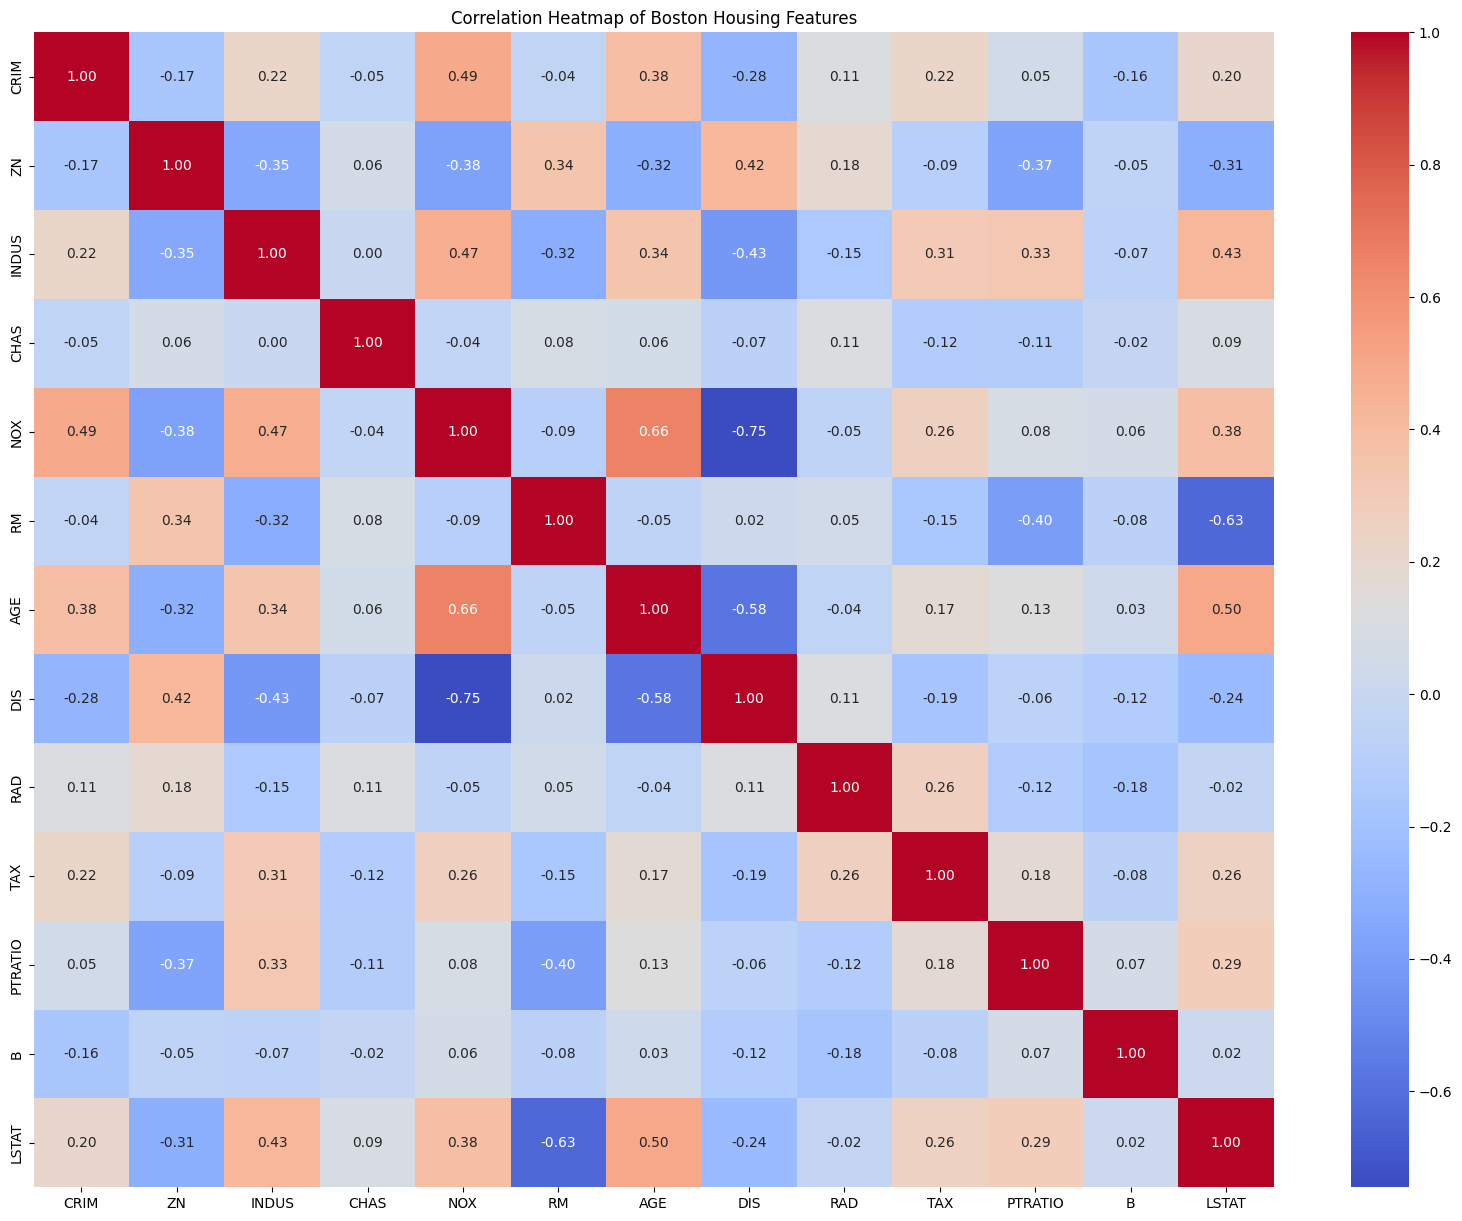

In [66]:
plt.figure(figsize=(20, 15))
corr_matrix = df.drop(columns=['MEDV']).corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Boston Housing Features")
plt.show()


# Regression model Build

In [18]:
# Imports
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error

In [34]:
## split data in to x, y
x = df.drop(columns= 'MEDV')
y = df['MEDV']

In [54]:
# train and test spliting
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state= 42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(190, 13)
(64, 13)
(190,)
(64,)


In [55]:
# Scalling the Data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)
X_train_scaled = pd.DataFrame(X_train, columns=x_train.columns)
X_test_scaled = pd.DataFrame(X_test, columns=x_test.columns)

In [56]:
#building model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [57]:
model.coef_

array([ 0.41829611,  0.16733803, -0.12741084,  0.17554015, -0.13755869,
        4.02087388, -1.27518713, -1.08911123,  0.21219524, -0.65939226,
       -1.42263465, -0.06664979, -0.20570445])

In [58]:
model.intercept_

np.float64(23.80263157894735)

In [103]:
y_pred1 = model.predict(X_test_scaled)

# Model evaluation metrics

In [99]:
r2 = r2_score(y_test, y_pred1)
mae = mean_absolute_error(y_test, y_pred1)
rmse = np.sqrt(mean_squared_error(y_test, y_pred1))
mse = mean_squared_error(y_test, y_pred1)

# Adjusted R2
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2_1 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("\n===== Test Set Performance =====")
print("R2 Score:", r2)
print("Adjusted R2:", adj_r2_1)
print("MAE:", mae)
print("RMSE:", rmse)
print("MSE:", mse)


===== Test Set Performance =====
R2 Score: 0.7001040995582942
Adjusted R2: 0.6221311654434507
MAE: 2.255930039396162
RMSE: 3.1949051581179004
MSE: 10.207418969368366


# Ensemble Technique and Random Forest Regressor

In [100]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train_scaled, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [101]:
y_pred2 = rf.predict(X_test_scaled)

In [102]:
r2 = r2_score(y_test, y_pred2)
mae = mean_absolute_error(y_test, y_pred2)
rmse = np.sqrt(mean_squared_error(y_test, y_pred2))
mse = mean_squared_error(y_test, y_pred2)

# Adjusted R2
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2_2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("\n===== Test Set Performance =====")
print("R2 Score:", r2)
print("Adjusted R2:", adj_r2_2)
print("MAE:", mae)
print("RMSE:", rmse)
print("MSE:", mse)


===== Test Set Performance =====
R2 Score: 0.7340494984745753
Adjusted R2: 0.6649023680779649
MAE: 2.103484374999999
RMSE: 3.008660004626231
MSE: 9.052035023437512


# Hypertuning

In [105]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(grid_search.best_params_)
best_rf = grid_search.best_estimator_

Fitting 5 folds for each of 162 candidates, totalling 810 fits
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [106]:
y_pred3 = best_rf.predict(X_test_scaled)

In [108]:
r2 = r2_score(y_test, y_pred3)
mae = mean_absolute_error(y_test, y_pred3)
rmse = np.sqrt(mean_squared_error(y_test, y_pred3))
mse = mean_squared_error(y_test, y_pred3)

# Adjusted R2
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2_3 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("\n===== Test Set Performance =====")
print("R2 Score:", r2)
print("Adjusted R2:", adj_r2_3)
print("MAE:", mae)
print("RMSE:", rmse)
print("MSE:", mse)


===== Test Set Performance =====
R2 Score: 0.74971196193296
Adjusted R2: 0.6846370720355296
MAE: 1.9842792731765146
RMSE: 2.9187221435378468
MSE: 8.518938951178162


# Final Conclusion
## Baseline Model: Linear Regression
- **R² Score:** ~0.70  
- **RMSE:** ~3.19  
- **MAE:** ~2.25  
## Random Forest (Default)
- **R² Score:** ~0.734  
- **RMSE:** ~3.00  
- **MAE:** ~2.10  
## Random Forest (After Hyperparameter Tuning)
- **R² Score:** ~0.75  
- **Adjusted R²:** ~0.68  
- **RMSE:** ~2.91  
- **MAE:** ~1.98  

Using **GridSearchCV with 5-fold cross-validation**, the tuned Random Forest model achieved the best performance.

### Improvements:
- Increased explained variance from **70% → 75%**
- Reduced prediction error (lower RMSE and MAE)
- Achieved better bias-variance balance

- Linear models provide strong interpretability but may struggle with nonlinear data.
- Tree-based models handle nonlinear patterns and multicollinearity effectively.
- Hyperparameter tuning significantly improves model performance.
- Cross-validation ensures reliable model selection and prevents overfitting.
# Final Outcome

The **tuned Random Forest model** is the best-performing model for this dataset, offering improved accuracy and better generalization compared to the baseline linear regression model.

This project demonstrates a complete machine learning workflow:
- Baseline modeling  
- Model comparison  
- Hyperparameter tuning  
- Proper evaluation on unseen data  